# Data Vis: Plotting Time Series Data
* Notebook 1: Data Preparation

## Setup

In [1]:
import numpy as np
import pandas as pd
import missingno as msno

# Data

In this notebook, we will use a private dataset about (solar) power generation and use of a single family house in Germany. The dataset contains the following columns:
- `timestamp`: The date and time of the measurement. The data is recorded every 1 hour.
- `total_consumption_kw`: The amount of power consumed per hour in kilowatts.
- `from_grid_kw`: The amount of power provided from the grid per hour in kilowatts.
- `from_pv_kw`: The amount of power generated by the solar panels per hour in kilowatts.
- `from_battery_kw`: The amount of power provided by the battery per hour in kilowatts.
- `to_grid_kw`: The amount of power provided to the grid per hour in kilowatts.
- `to_battery_kw`: The amount of power provided to the battery per hour in kilowatts.
- `battery_percent`: The average percentage of battery charge at the time of measurement.
- `battery_kwh`: The average amount of power in the battery at the time of measurement in kilowatt hours.
- various weather data, including temperature, humidity, precipitation, wind speed, and solar radiation (ghi, dni, dhi).

In [2]:
data = pd.read_csv("solar.csv")

In [3]:
data.head()

,timestamp,total_consumption_kw,from_grid_kw,from_pv_kw,from_battery_kw,to_grid_kw,to_battery_kw,battery_percent,battery_kwh,checksum,...,wind_speed_10m,wind_speed_100m,ghi,dni,dhi,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration
0,2024-05-01 00:00:00+00:00,0.135,0.0,0.0,0.135,0.0,0.0,0.726,3.7026,0.0,...,10.086427,24.144167,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.001960
1,2024-05-01 01:00:00+00:00,0.132,0.0,0.0,0.132,0.0,0.0,0.684,3.4884,0.0,...,9.885262,24.365910,0.0,0.0,0.0,91.0,0.0,16.0,90.0,0.010369
2,2024-05-01 02:00:00+00:00,0.133,0.0,0.0,0.133,0.0,0.0,0.642,3.2742,0.0,...,9.693296,23.469128,0.0,0.0,0.0,79.0,0.0,13.0,76.0,0.015774
3,2024-05-01 03:00:00+00:00,0.093,0.0,0.0,0.093,0.0,0.0,0.610,3.1110,0.0,...,7.895416,18.733839,0.0,0.0,0.0,21.0,0.0,21.0,0.0,0.006033
4,2024-05-01 04:00:00+00:00,0.087,0.0,0.0,0.087,0.0,0.0,0.578,2.9478,0.0,...,6.120000,15.517629,0.0,0.0,0.0,39.0,0.0,39.0,0.0,0.000000


In [4]:
data.shape

(8634, 24)

In [5]:
data.columns

Index(['timestamp', 'total_consumption_kw', 'from_grid_kw', 'from_pv_kw',
       'from_battery_kw', 'to_grid_kw', 'to_battery_kw', 'battery_percent',
       'battery_kwh', 'checksum', 'temperature_2m', 'relative_humidity_2m',
       'apparent_temperature', 'precipitation', 'wind_speed_10m',
       'wind_speed_100m', 'ghi', 'dni', 'dhi', 'cloud_cover',
       'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
       'et0_fao_evapotranspiration'],
      dtype='object')

Use thew `missingno` package to visualize the missing values in the dataframe.

<Axes: >

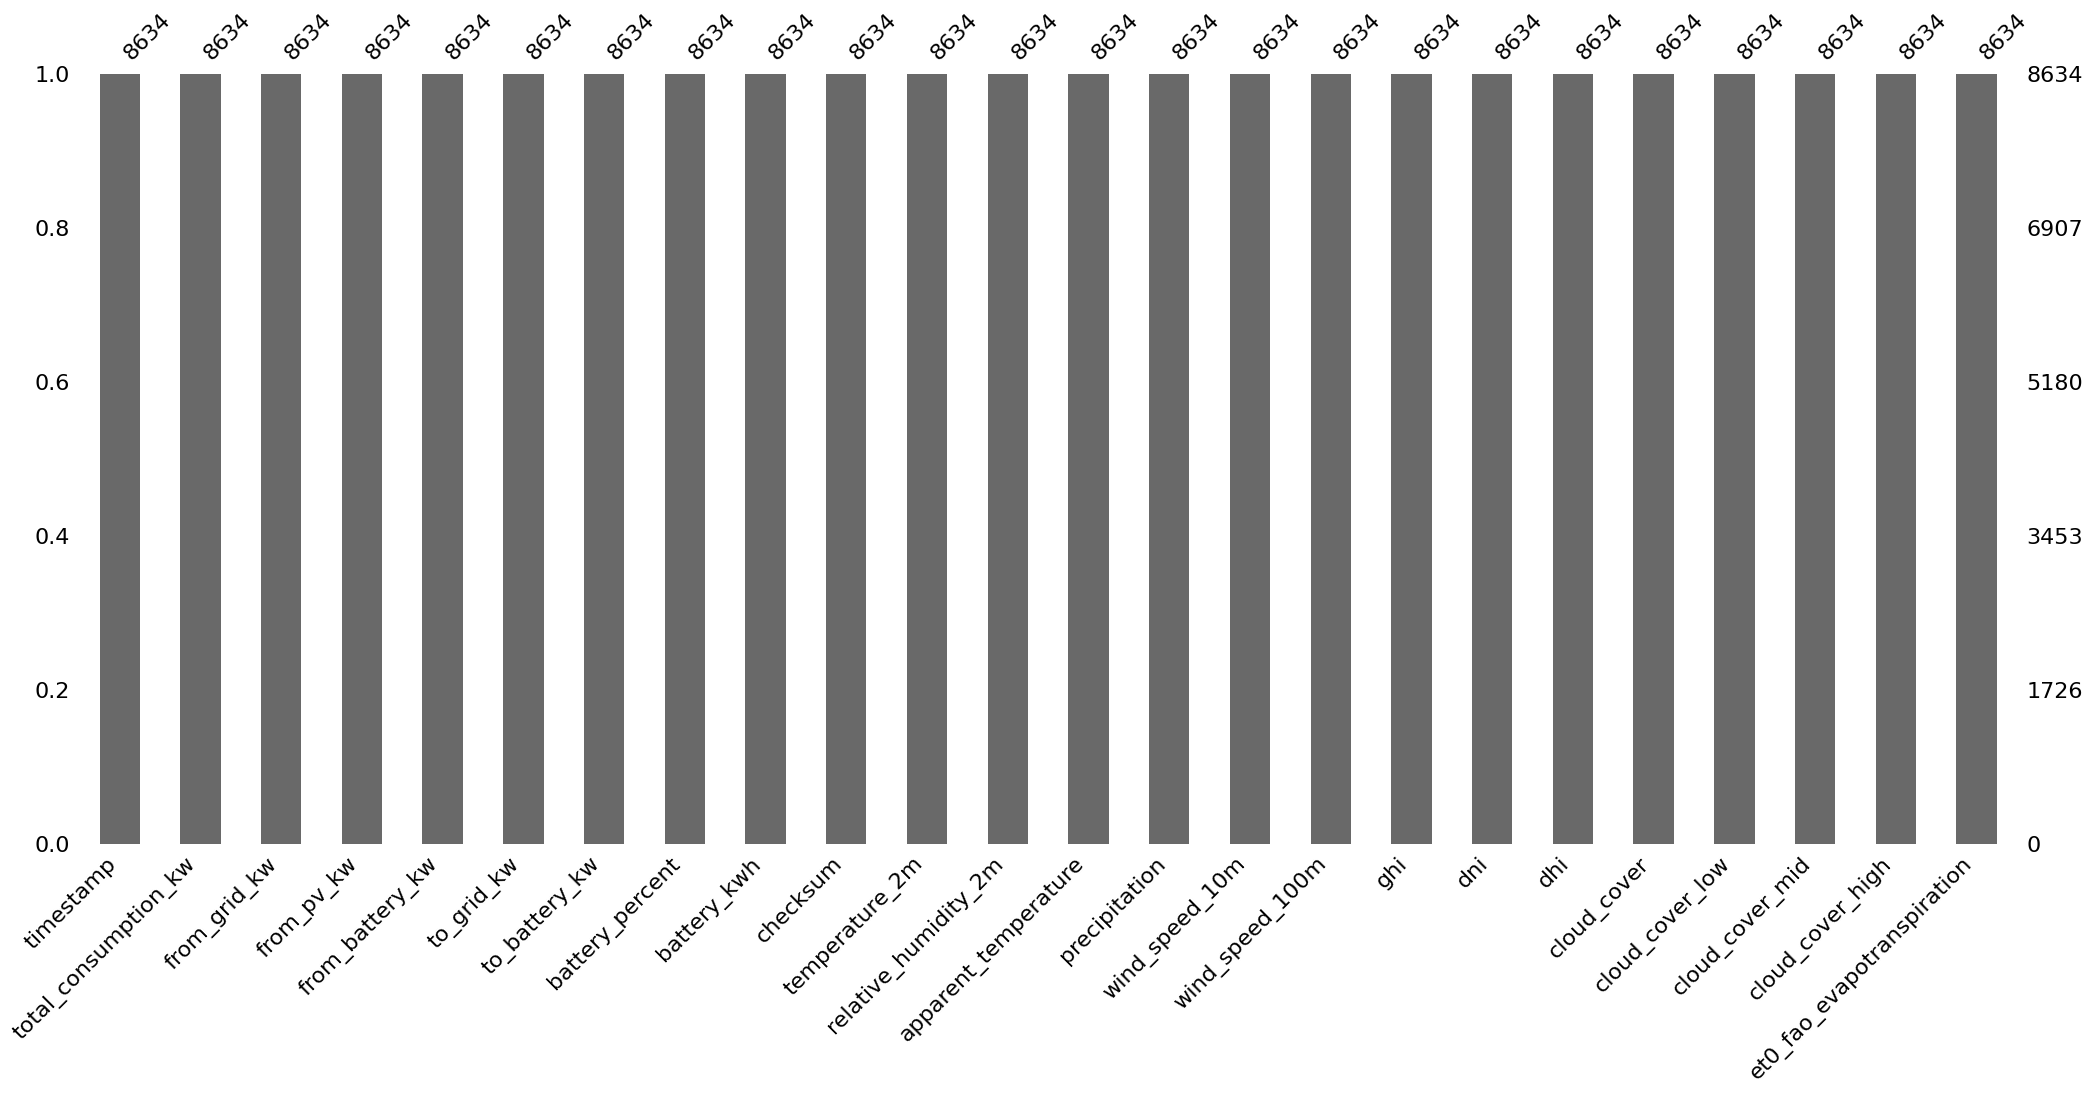

In [6]:
msno.bar(data)

# Pandas Datetime Properties

Check, if the `timestamp` column is in datetime format. If not, convert it to datetime format using `pd.to_datetime()`. Then, set the `timestamp` column as the index of the dataframe.

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8634 entries, 0 to 8633
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   timestamp                   8634 non-null   object 
 1   total_consumption_kw        8634 non-null   float64
 2   from_grid_kw                8634 non-null   float64
 3   from_pv_kw                  8634 non-null   float64
 4   from_battery_kw             8634 non-null   float64
 5   to_grid_kw                  8634 non-null   float64
 6   to_battery_kw               8634 non-null   float64
 7   battery_percent             8634 non-null   float64
 8   battery_kwh                 8634 non-null   float64
 9   checksum                    8634 non-null   float64
 10  temperature_2m              8634 non-null   float64
 11  relative_humidity_2m        8634 non-null   float64
 12  apparent_temperature        8634 non-null   float64
 13  precipitation               8634 

In [8]:
data["timestamp"] = pd.to_datetime(data["timestamp"])

Now, we can use various pandas datetime properties to extract useful information from the `timestamp`. 

In [9]:
data["timestamp"].min(), data["timestamp"].max()

(Timestamp('2024-05-01 00:00:00+0000', tz='UTC'),
 Timestamp('2025-04-27 00:00:00+0000', tz='UTC'))

In [10]:
data["timestamp"].max() - data["timestamp"].min()

Timedelta('361 days 00:00:00')

We can use the `dt` accessor to extract the year, month, day, and hour from the timestamp. We can also create a new column that indicates whether the timestamp is on a weekend or a weekday.

In [11]:
data["year"] = data["timestamp"].dt.year
data["month"] = data["timestamp"].dt.month_name()
data["day"] = data["timestamp"].dt.day
data["hour"] = data["timestamp"].dt.hour
data["weekday"] = data["timestamp"].dt.day_name()
data["is_weekend"] = np.where(data["weekday"].isin(["Saturday", "Sunday"]), 1, 0)   

In [12]:
data.head()

,timestamp,total_consumption_kw,from_grid_kw,from_pv_kw,from_battery_kw,to_grid_kw,to_battery_kw,battery_percent,battery_kwh,checksum,...,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,year,month,day,hour,weekday,is_weekend
0,2024-05-01 00:00:00+00:00,0.135,0.0,0.0,0.135,0.0,0.0,0.726,3.7026,0.0,...,0.0,0.0,100.0,0.001960,2024,May,1,0,Wednesday,0
1,2024-05-01 01:00:00+00:00,0.132,0.0,0.0,0.132,0.0,0.0,0.684,3.4884,0.0,...,0.0,16.0,90.0,0.010369,2024,May,1,1,Wednesday,0
2,2024-05-01 02:00:00+00:00,0.133,0.0,0.0,0.133,0.0,0.0,0.642,3.2742,0.0,...,0.0,13.0,76.0,0.015774,2024,May,1,2,Wednesday,0
3,2024-05-01 03:00:00+00:00,0.093,0.0,0.0,0.093,0.0,0.0,0.610,3.1110,0.0,...,0.0,21.0,0.0,0.006033,2024,May,1,3,Wednesday,0
4,2024-05-01 04:00:00+00:00,0.087,0.0,0.0,0.087,0.0,0.0,0.578,2.9478,0.0,...,0.0,39.0,0.0,0.000000,2024,May,1,4,Wednesday,0


We can use the extracted information to group and aggregate the data. For example, we can group the data by weekday and calculate the average power consumption for each weekday.

In [13]:
data.groupby("weekday")["total_consumption_kw"].mean().sort_values(ascending=False)

weekday
Monday       0.385401
Friday       0.334325
Sunday       0.326238
Tuesday      0.320198
Thursday     0.320120
Wednesday    0.307356
Saturday     0.290020
Name: total_consumption_kw, dtype: float64

Working with a datetime index (i.e. `DatetimeIndex`) provides powerful functionalities. For example, we do not need the `dt` accessor to get the time series properties, but have these properties available on the index directly.

In [14]:
data.set_index("timestamp", inplace=True)

In [15]:
data_202503 = data["2025-03-01":"2025-03-31"]

In [16]:
data_202503.head()

,total_consumption_kw,from_grid_kw,from_pv_kw,from_battery_kw,to_grid_kw,to_battery_kw,battery_percent,battery_kwh,checksum,temperature_2m,...,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,year,month,day,hour,weekday,is_weekend
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-03-01 00:00:00+00:00,0.101,0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.813,...,100.0,35.0,0.0,0.0,2025,March,1,0,Saturday,1
2025-03-01 01:00:00+00:00,0.101,0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.963,...,100.0,70.0,0.0,0.0,2025,March,1,1,Saturday,1
2025-03-01 02:00:00+00:00,0.102,0.102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.963,...,100.0,11.0,0.0,0.0,2025,March,1,2,Saturday,1
2025-03-01 03:00:00+00:00,0.127,0.127,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.013,...,100.0,32.0,0.0,0.0,2025,March,1,3,Saturday,1
2025-03-01 04:00:00+00:00,0.181,0.181,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.863,...,100.0,97.0,0.0,0.0,2025,March,1,4,Saturday,1


In [17]:
data_202503.tail()

,total_consumption_kw,from_grid_kw,from_pv_kw,from_battery_kw,to_grid_kw,to_battery_kw,battery_percent,battery_kwh,checksum,temperature_2m,...,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,year,month,day,hour,weekday,is_weekend
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-03-31 19:00:00+00:00,0.181,0.000,0.326,0.000,0.144,0.0,1.000,5.1000,-0.001,7.963,...,4.0,1.0,0.0,0.030237,2025,March,31,19,Monday,0
2025-03-31 20:00:00+00:00,0.184,0.000,0.000,0.184,0.000,0.0,0.957,4.8807,0.000,6.613,...,1.0,1.0,0.0,0.019163,2025,March,31,20,Monday,0
2025-03-31 21:00:00+00:00,0.218,0.000,0.000,0.218,0.000,0.0,0.884,4.5084,0.000,5.363,...,0.0,0.0,0.0,0.006362,2025,March,31,21,Monday,0
2025-03-31 22:00:00+00:00,0.299,0.002,0.000,0.297,0.000,0.0,0.789,4.0239,0.000,4.513,...,0.0,0.0,0.0,0.000000,2025,March,31,22,Monday,0
2025-03-31 23:00:00+00:00,0.110,0.000,0.000,0.110,0.000,0.0,0.715,3.6465,0.000,3.713,...,0.0,0.0,0.0,0.000000,2025,March,31,23,Monday,0


Another useful functionality is the `resample()` method, which allows us to group the data by a specific time frequency. For example, we can resample the data to daily frequency and calculate the average power generation and consumption for each day. Note that we actually should rename the columns from "_kw" to "_kwh" to indicate that the values are in kilowatt hours.


In [18]:
data_daily = data[["total_consumption_kw", "from_grid_kw", "from_pv_kw", "from_battery_kw", "to_grid_kw", "to_battery_kw"]].resample("D").sum()

In [20]:
data_daily.head()

,total_consumption_kw,from_grid_kw,from_pv_kw,from_battery_kw,to_grid_kw,to_battery_kw
timestamp,,,,,,
2024-05-01 00:00:00+00:00,9.754,0.123,46.160,1.503,34.756,3.275
2024-05-02 00:00:00+00:00,3.324,0.000,51.742,1.318,47.560,2.170
2024-05-03 00:00:00+00:00,14.553,1.488,5.702,9.127,0.425,1.327
2024-05-04 00:00:00+00:00,6.047,1.201,24.172,0.587,13.796,6.085
2024-05-05 00:00:00+00:00,11.369,0.089,18.426,3.372,5.168,5.346
